In [1]:
!pip install scikit-learn pandas numpy joblib --quiet

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

1. ทำการตรวจสอบข้อมูลก่อนนำข้อมูลไปใช้(จำนวนข้อมูลทั้งหมด , ตัวแปรทั้งหมด)

In [3]:
data = pd.read_csv('airlines_reviews.csv')

print("รูปร่างของข้อมูล:", data.shape)
print("\n5 แถวแรก:")
print(data.head())
print("\nสถิติพื้นฐาน:")
print(data.describe())
print("\nจำนวน missing values:")
print(data.isnull().sum())

รูปร่างของข้อมูล: (8100, 17)

5 แถวแรก:
                                  Title              Name Review Date  \
0                    Flight was amazing  Alison Soetantyo  2024-03-01   
1  seats on this aircraft are dreadful      Robert Watson  2024-02-21   
2          Food was plentiful and tasty             S Han  2024-02-20   
3          “how much food was available          D Laynes  2024-02-19   
4       “service was consistently good”         A Othman   2024-02-19   

              Airline Verified  \
0  Singapore Airlines     True   
1  Singapore Airlines     True   
2  Singapore Airlines     True   
3  Singapore Airlines     True   
4  Singapore Airlines     True   

                                             Reviews Type of Traveller  \
0    Flight was amazing. The crew onboard this fl...      Solo Leisure   
1    Booking an emergency exit seat still meant h...      Solo Leisure   
2    Excellent performance on all fronts. I would...    Family Leisure   
3   Pretty comfortab

In [4]:
print('Info :\n', data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Title                   8100 non-null   object
 1   Name                    8100 non-null   object
 2   Review Date             8100 non-null   object
 3   Airline                 8100 non-null   object
 4   Verified                8100 non-null   object
 5   Reviews                 8100 non-null   object
 6   Type of Traveller       8100 non-null   object
 7   Month Flown             8100 non-null   object
 8   Route                   8100 non-null   object
 9   Class                   8100 non-null   object
 10  Seat Comfort            8100 non-null   int64 
 11  Staff Service           8100 non-null   int64 
 12  Food & Beverages        8100 non-null   int64 
 13  Inflight Entertainment  8100 non-null   int64 
 14  Value For Money         8100 non-null   int64 
 15  Over

2.เคลียร์ค่าช่องว่างในคอลัมน์และบันทึกเก็บเป็นไฟล์ cleaned_shot_data.csv

In [5]:
# เลือกเฉพาะคอลัมน์ที่เป็นคะแนน (Features) และเป้าหมาย (Target)
features = ['Seat Comfort', 'Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'Overall Rating', 'Recommended']

# ตัดแถวที่มีค่าว่าง (Missing Value) ออก
data_cleaned = data[features].dropna()

# แปลงค่า 'yes' เป็น 1 และ 'no' เป็น 0 สำหรับทำ Classification
data_cleaned['Recommended'] = data_cleaned['Recommended'].map({'yes': 1, 'no': 0})

print('Number of records after cleaning:', data_cleaned.shape[0])

# บันทึกเป็นไฟล์ใหม่
data_cleaned.to_csv('cleaned_airline_data.csv', index=False)
print('บันทึกไฟล์ cleaned_airline_data.csv สำเร็จแล้ว!')

Number of records after cleaning: 8100
บันทึกไฟล์ cleaned_airline_data.csv สำเร็จแล้ว!


3.ทำการตรวจสอบข้อมูลอีกรอบก่อนนำข้อมูลไปใช้

In [6]:
data = pd.read_csv('cleaned_airline_data.csv', encoding='latin1', engine='python')
newdf1 = data
print('Shape :',newdf1.shape)
print('\n', newdf1.describe())

Shape : (8100, 7)

        Seat Comfort  Staff Service  Food & Beverages  Inflight Entertainment  \
count   8100.000000    8100.000000       8100.000000             8100.000000   
mean       3.414815       3.569877          3.384074                3.636790   
std        1.397183       1.527436          1.455694                1.309564   
min        1.000000       1.000000          1.000000                0.000000   
25%        2.000000       2.000000          2.000000                3.000000   
50%        4.000000       4.000000          4.000000                4.000000   
75%        5.000000       5.000000          5.000000                5.000000   
max        5.000000       5.000000          5.000000                5.000000   

       Value For Money  Overall Rating  Recommended  
count      8100.000000     8100.000000  8100.000000  
mean          3.148642        5.632469     0.529259  
std           1.589377        3.523664     0.499174  
min           1.000000        1.000000     

4.สร้างตารางความสัมพันธ์ ( Correlation Heatmap ) และ สร้าง (Box Plot)

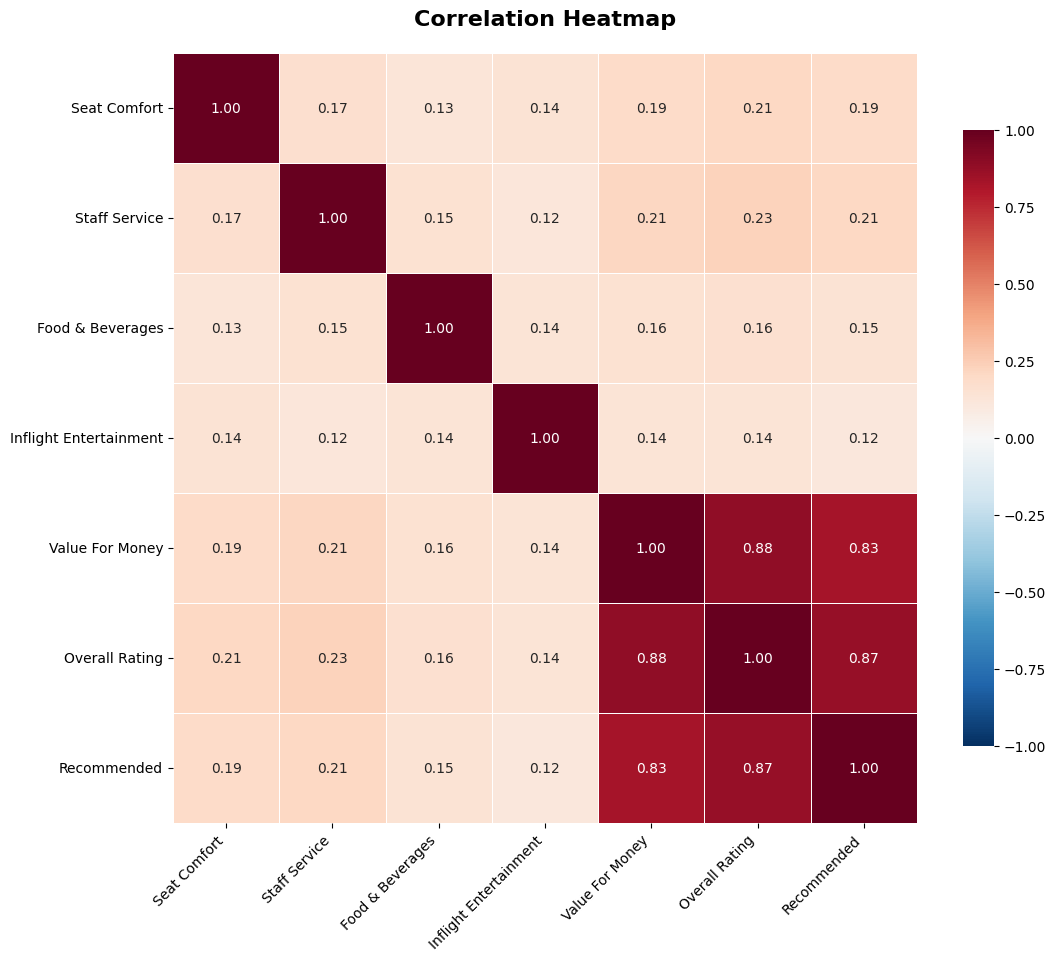

In [7]:
# 1. เลือกเฉพาะข้อมูลตัวเลขและหาค่า Correlation
numeric_data = newdf1.select_dtypes(include=['number'])
correlation_matrix1 = numeric_data.corr()

# 2. ตั้งค่าขนาดกราฟ
plt.figure(figsize=(12, 10))

# 3. สร้าง Heatmap แบบพรีเมียม 🌟
sns.heatmap(correlation_matrix1,
            annot=True,
            cmap='RdBu_r',        # เปลี่ยนโทนสีเป็น แดง-ขาว-น้ำเงิน (สีสว่างและตัดกันชัดเจน)
            center=0,
            vmin=-1, vmax=1,      # ล็อคสเกลสีให้อยู่ระหว่าง -1 ถึง 1 เสมอ (สีจะเป๊ะขึ้น)
            fmt='.2f',
            linewidths=0.5,       # เพิ่มเส้นขอบสีขาวบางๆ แบ่งระหว่างช่องให้ดูสะอาดตา
            cbar_kws={"shrink": .8}) # หดความยาวแถบสีด้านขวาลงนิดนึงให้สมส่วนกับกราฟ

# 4. ตกแต่งข้อความและแกน
plt.title('Correlation Heatmap', fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right') # เอียงตัวหนังสือแกน X 45 องศา จะได้ไม่ชนกัน
plt.yticks(rotation=0)

# 5. แสดงผล
plt.show()

⏳ กำลังโหลดและทำความสะอาดข้อมูล...
✅ ข้อมูลพร้อมแล้ว! กำลังวาดกราฟ...


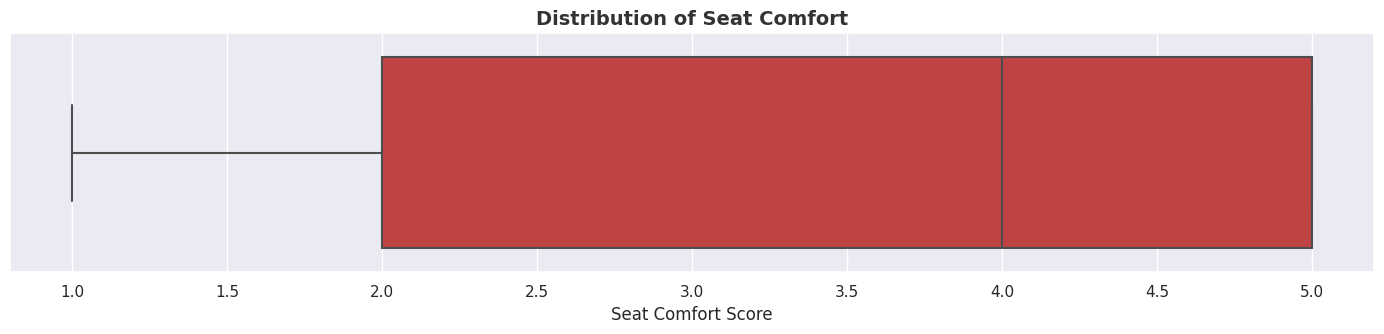

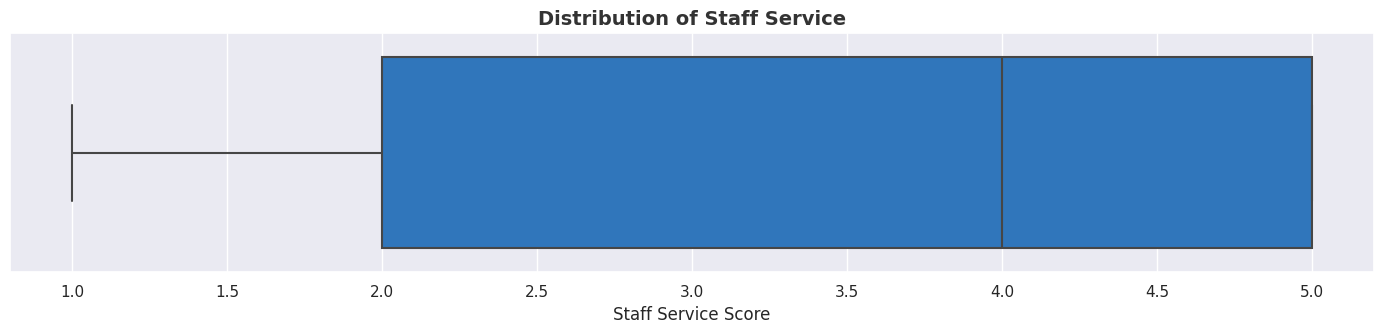

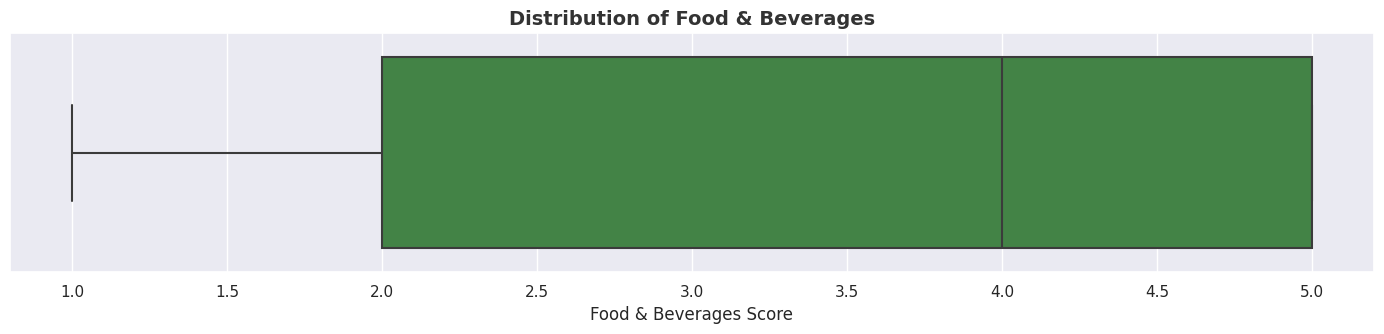

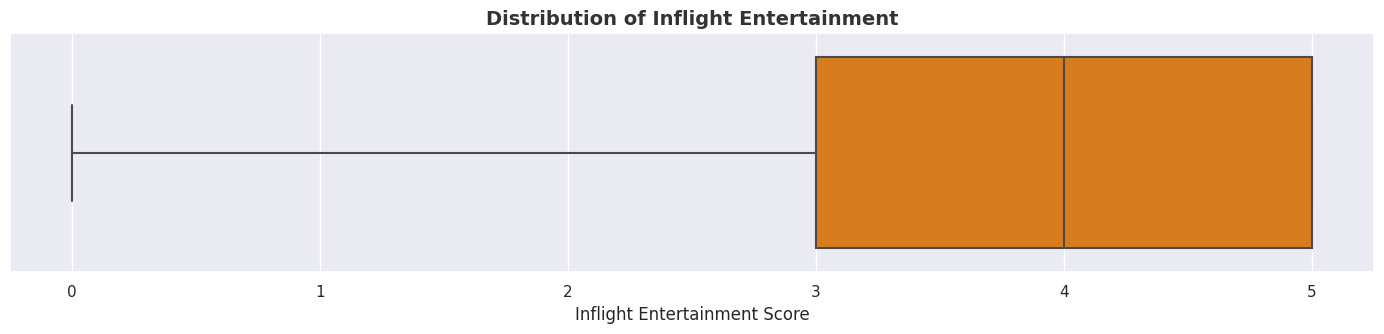

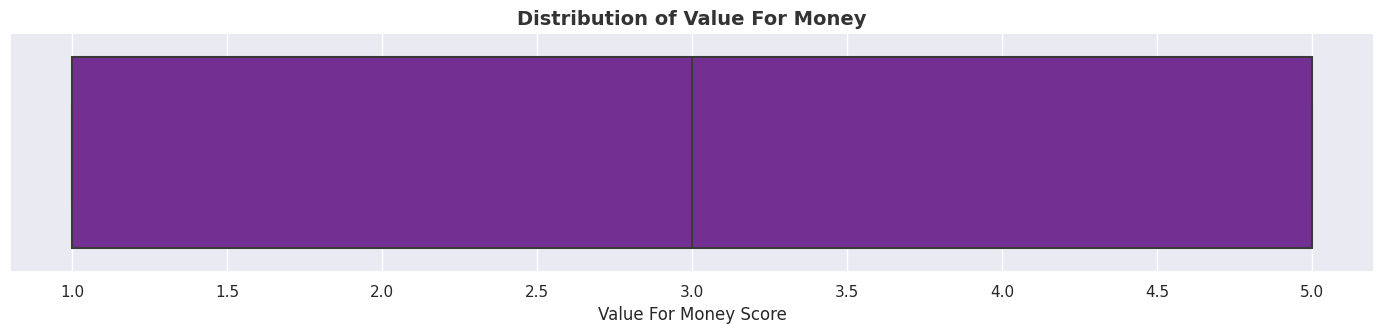

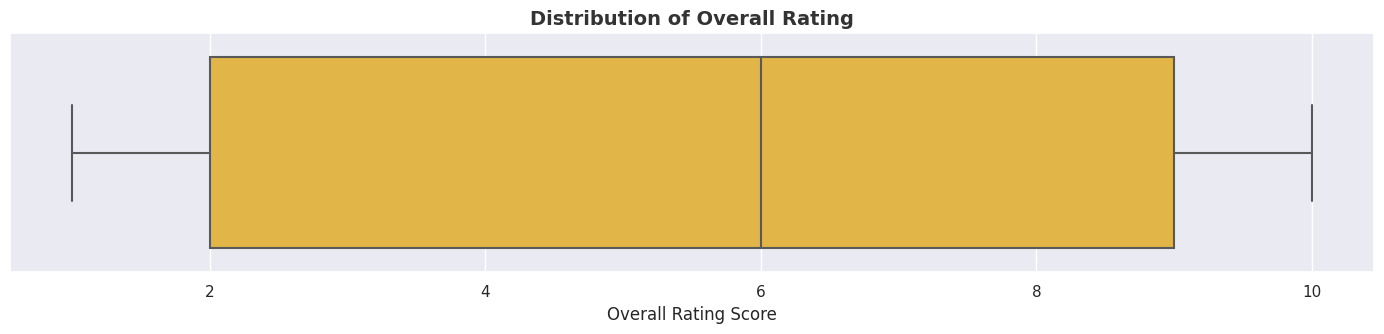

In [8]:
sns.set_theme(style="darkgrid")

def prep_airline_data(csv_filename):
    """
    ฟังก์ชันโหลดข้อมูล ตรวจสอบคอลัมน์ และคลีนค่าว่าง
    """
    target_cols = [
        'Seat Comfort', 'Staff Service', 'Food & Beverages',
        'Inflight Entertainment', 'Value For Money', 'Overall Rating'
    ]

    try:
        raw_data = pd.read_csv(csv_filename)

        if not set(target_cols).issubset(raw_data.columns):
            missing = list(set(target_cols) - set(raw_data.columns))
            raise ValueError(f"ไฟล์ขาดคอลัมน์เหล่านี้: {missing}")

        clean_df = raw_data[target_cols].copy()
        for col in target_cols:
            clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

        return clean_df.dropna().reset_index(drop=True)

    except FileNotFoundError:
        print(f"❌ หาไฟล์ไม่พบ: เช็คชื่อไฟล์ '{csv_filename}' อีกครั้งนะครับ")
    except Exception as e:
        print(f"⚠️ เกิดข้อผิดพลาดระหว่างโหลดข้อมูล: {e}")

    return None

def generate_custom_boxplots(df):
    custom_colors = ['#D32F2F', '#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#FBC02D']

    for index, col_name in enumerate(df.columns):
        plt.figure(figsize=(14, 3.5))

        # เลือกสีจาก List โดยใช้ index เป็นตัวกำหนด
        box_color = custom_colors[index % len(custom_colors)]

        # สร้าง Boxplot
        sns.boxplot(x=df[col_name], color=box_color, linewidth=1.5, fliersize=6)

        # ตกแต่งชื่อกราฟและแกน
        plt.title(f'Distribution of {col_name}', fontsize=14, fontweight='bold', color='#333333')
        plt.xlabel(f'{col_name} Score', fontsize=12)

        # จัดเลย์เอาต์ให้พอดีและแสดงผล
        plt.tight_layout()
        plt.show()
        plt.close()

# ==========================================
# ส่วนเรียกใช้งานหลัก
# ==========================================
if __name__ == "__main__":
    dataset_path = "cleaned_airline_data.csv"

    print("⏳ กำลังโหลดและทำความสะอาดข้อมูล...")
    processed_data = prep_airline_data(dataset_path)

    if processed_data is not None:
        print("✅ ข้อมูลพร้อมแล้ว! กำลังวาดกราฟ...")
        generate_custom_boxplots(processed_data)

5.กำหนดตัวแปร X ตัวแปร Y

In [9]:
feature_columns = ['Seat Comfort', 'Staff Service', 'Food & Beverages',
            'Inflight Entertainment', 'Value For Money', 'Overall Rating']
target_column = 'Recommended'

X_data = newdf1[feature_columns]
y_data = newdf1[target_column]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, train_size=0.8, stratify=y_data, random_state=42)

print("- สัดส่วนผู้โดยสารที่ 'แนะนำ' สายการบินในชุด Train: {:.2%}".format(y_train.mean()))
print("- สัดส่วนผู้โดยสารที่ 'แนะนำ' สายการบินในชุด Test: {:.2%}".format(y_test.mean()))

- สัดส่วนผู้โดยสารที่ 'แนะนำ' สายการบินในชุด Train: 52.93%
- สัดส่วนผู้โดยสารที่ 'แนะนำ' สายการบินในชุด Test: 52.90%


6.เปรียบเทียบโมเดลเพื่อเป็นตัวเลือกในการตัดสินใจ

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# เตรียมโมเดลทั้งหมดที่ต้องการเปรียบเทียบ
classifiers = [
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(n_estimators=100, random_state=42),
    KNeighborsClassifier(),
]

best_acc = 0
best_model_name = ""
best_model = None

for clf in classifiers:
    # 1. เทรนโมเดล
    clf.fit(X_train, y_train)
    name = clf.__class__.__name__

    print("="*50)
    print(f"🚀 Model: {name}")
    print("="*50)

    # 2. นำโมเดลไปทำนายผลกับชุด Test
    test_predictions = clf.predict(X_test)

    # 3. หา Accuracy (ความแม่นยำรวม)
    acc = accuracy_score(y_test, test_predictions)
    print(f"🎯 ความแม่นยำ (Accuracy): {acc:.2%}\n")

    # 4. แสดงรายงานผล Classification แบบเจาะลึก
    # (แสดง Precision, Recall, F1-Score สำหรับทั้งกลุ่ม 'แนะนำ' และ 'ไม่แนะนำ')
    print("📊 Classification Report:")
    print(classification_report(y_test, test_predictions, target_names=['Not Recommended (0)', 'Recommended (1)']))

    # เก็บแชมป์โมเดลที่แม่นยำที่สุดไว้
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_model = clf

print("="*50)
print(f"🏆 สรุปโมเดลที่ชนะเลิศคือ: {best_model_name} (ความแม่นยำ {best_acc:.2%})")
print("="*50)

# หากต้องการเซฟโมเดลที่ชนะไปใช้ต่อ สามารถใช้คำสั่งนี้ได้เลย:
# joblib.dump(best_model, 'best_airline_model.pkl')

🚀 Model: DecisionTreeClassifier
🎯 ความแม่นยำ (Accuracy): 91.42%

📊 Classification Report:
                     precision    recall  f1-score   support

Not Recommended (0)       0.91      0.91      0.91       763
    Recommended (1)       0.92      0.92      0.92       857

           accuracy                           0.91      1620
          macro avg       0.91      0.91      0.91      1620
       weighted avg       0.91      0.91      0.91      1620

🚀 Model: RandomForestClassifier
🎯 ความแม่นยำ (Accuracy): 93.40%

📊 Classification Report:
                     precision    recall  f1-score   support

Not Recommended (0)       0.93      0.93      0.93       763
    Recommended (1)       0.94      0.93      0.94       857

           accuracy                           0.93      1620
          macro avg       0.93      0.93      0.93      1620
       weighted avg       0.93      0.93      0.93      1620

🚀 Model: KNeighborsClassifier
🎯 ความแม่นยำ (Accuracy): 93.33%

📊 Classification Re

7.สรุปโมเดลที่ชนะคือ " RandomForest"

In [13]:
from sklearn.ensemble import RandomForestClassifier

# สร้างโมเดล (หรือ Pipeline) และตั้งชื่อตัวแปร
pipeline = RandomForestClassifier()

# สอนโมเดลด้วยข้อมูล Train
pipeline.fit(X_train, y_train)

# -------------------------------

RandomForestClassifier()

In [14]:
from sklearn.metrics import precision_score

y_pred = pipeline.predict(X_test)
precision = precision_score(y_test, y_pred)
print(f'RandomForest Precision: {precision * 100:.2f}%')

RandomForest Precision: 93.78%


In [15]:
# ตรวจสอบสัดส่วนของข้อมูลเป้าหมาย (Class Distribution)
print("📊 จำนวนผู้โดยสารที่ 'แนะนำ(1)' และ 'ไม่แนะนำ(0)':")
print(f"{data['Recommended'].value_counts()}")

print("\n📈 คิดเป็นเปอร์เซ็นต์:")
print((data['Recommended'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

📊 จำนวนผู้โดยสารที่ 'แนะนำ(1)' และ 'ไม่แนะนำ(0)':
Recommended
1    4287
0    3813
Name: count, dtype: int64

📈 คิดเป็นเปอร์เซ็นต์:
Recommended
1    52.93%
0    47.07%
Name: proportion, dtype: object


In [16]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# ==========================================
# 1. ฟังก์ชัน evaluate_model (ใช้ตัวเดิมที่คุณมี)
# ==========================================
RANDOM_SEED = 42
all_results = {}

def evaluate_model(model, X, y, model_name):
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    std_score = scores.std()

    print(f"📊 {model_name}:")
    print(f"   ความแม่นยำเฉลี่ย (Mean): {mean_score:.2%}")
    print(f"   ความแกว่งของข้อมูล (Std): +/- {std_score:.4f}\n")
    return mean_score, std_score

# ==========================================
# 2. เริ่มทำงานโดยใช้ Random Forest
# ==========================================

# กำหนด Random Forest Model
# ไม่ต้องใช้ DecisionTreeClassifier(max_depth=1) แล้ว เพราะ RF สร้างต้นไม้ให้เอง
rf_model = RandomForestClassifier(
    n_estimators=200,      # จำนวนต้นไม้ในป่า (คล้าย n_estimators ใน Ada)
    max_depth=None,        # ปล่อยให้ต้นไม้โตได้เต็มที่ (หรือกำหนดเลขเพื่อคุมขนาด)
    random_state=RANDOM_SEED,
    n_jobs=-1              # ใช้ CPU ทุกตัวในเครื่องช่วยประมวลผล (จะรันเร็วขึ้น)
)

# ประเมินผลโมเดลและเก็บค่าไว้ใน all_results
rf_mean, rf_std = evaluate_model(rf_model, X_train, y_train, "Random Forest (Baseline)")
all_results['RandomForest'] = {'mean': rf_mean, 'std': rf_std, 'model': rf_model}

# ถ้าต้องการฝึกโมเดลจริงเพื่อเอาไปใช้ต่อ
rf_model.fit(X_train, y_train)

📊 Random Forest (Baseline):
   ความแม่นยำเฉลี่ย (Mean): 93.66%
   ความแกว่งของข้อมูล (Std): +/- 0.0041



RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
import pandas as pd

# Load data
original_full_data = pd.read_csv('airlines_reviews.csv')

# กรองข้อมูล
data_compare = original_full_data.dropna(subset=['Class', 'Recommended', 'Overall Rating']).copy()

# แปลง Recommended เป็นตัวเลข
if data_compare['Recommended'].dtype == 'O':
    data_compare['Recommended_Num'] = data_compare['Recommended'].str.lower().map({'yes': 1, 'no': 0})
else:
    data_compare['Recommended_Num'] = data_compare['Recommended']

# ฟังก์ชันช่วยพิมพ์ผลลัพธ์เพื่อลดความซ้ำซ้อนและกัน Error
def print_summary(class_name, mask):
    df_filtered = data_compare[mask]
    nb_pass = len(df_filtered)

    print(f'💺 {class_name}:')
    print(f'จำนวนผู้โดยสารทั้งหมด (Total Passengers) : {nb_pass}')

    if nb_pass > 0:
        avg_rating = df_filtered['Overall Rating'].mean()
        nb_recommend = df_filtered[df_filtered['Recommended_Num'] == 1].shape[0]
        rec_rate = nb_recommend / nb_pass

        print(f'คะแนนภาพรวมเฉลี่ย (Average Overall Rating) : {avg_rating:.2f} / 10')
        print(f'จำนวนคนที่แนะนำสายการบิน (Total Recommended) : {nb_recommend}')
        print(f'สัดส่วนผู้โดยสารที่แนะนำ (Recommendation Rate) : {rec_rate:.2%}')
    else:
        print("❌ ไม่พบข้อมูลสำหรับ Class นี้")
    print('\n' + '-'*45 + '\n')

# 1. Business Class
print_summary('Business Class ', data_compare['Class'] == 'Business Class')

# 2. Economy Class
print_summary('Economy Class', data_compare['Class'] == 'Economy Class')

# 3. First Class (เช็คตัวสะกดให้ตรงกับในไฟล์ CSV เช่น 'First Class')
print_summary('First Class', data_compare['Class'].str.contains('First Class', case=False))

💺 Business Class :
จำนวนผู้โดยสารทั้งหมด (Total Passengers) : 2104
คะแนนภาพรวมเฉลี่ย (Average Overall Rating) : 6.65 / 10
จำนวนคนที่แนะนำสายการบิน (Total Recommended) : 1398
สัดส่วนผู้โดยสารที่แนะนำ (Recommendation Rate) : 66.44%

---------------------------------------------

💺 Economy Class:
จำนวนผู้โดยสารทั้งหมด (Total Passengers) : 5504
คะแนนภาพรวมเฉลี่ย (Average Overall Rating) : 5.18 / 10
จำนวนคนที่แนะนำสายการบิน (Total Recommended) : 2586
สัดส่วนผู้โดยสารที่แนะนำ (Recommendation Rate) : 46.98%

---------------------------------------------

💺 First Class:
จำนวนผู้โดยสารทั้งหมด (Total Passengers) : 121
คะแนนภาพรวมเฉลี่ย (Average Overall Rating) : 7.60 / 10
จำนวนคนที่แนะนำสายการบิน (Total Recommended) : 93
สัดส่วนผู้โดยสารที่แนะนำ (Recommendation Rate) : 76.86%

---------------------------------------------



In [18]:
import pandas as pd

col_airline = 'Airline'

print("⏳ กำลังคำนวณสถิติของทุกสายการบิน...\n")

# 1. เตรียมข้อมูล
data_all = original_full_data.dropna(subset=[col_airline, 'Recommended', 'Overall Rating']).copy()

if data_all['Recommended'].dtype == 'O':
    data_all['Recommended_Num'] = data_all['Recommended'].map({'yes': 1, 'no': 0})
else:
    data_all['Recommended_Num'] = data_all['Recommended']

# 2. จัดกลุ่มและคำนวณ
airline_stats = data_all.groupby(col_airline).agg(
    Total_Reviews=('Overall Rating', 'count'),
    Total_Overall_Rating=('Overall Rating', 'sum'),
    Total_Recommended=('Recommended_Num', 'sum')
).reset_index()

# 3. คำนวณค่าเฉลี่ย
airline_stats['Average_Rating'] = (airline_stats['Total_Overall_Rating'] / airline_stats['Total_Reviews']).round(2)
airline_stats['Recommendation_Rate (%)'] = ((airline_stats['Total_Recommended'] / airline_stats['Total_Reviews']) * 100).round(2)

# 4. จัดเรียงลำดับ
airline_stats = airline_stats.sort_values(by='Total_Reviews', ascending=False).reset_index(drop=True)

# ==========================================
# 5. แสดงผลลัพธ์แบบข้อความ (ให้เหมือนในรูปที่คุณต้องการ)
# ==========================================
print("🏆 สถิติเปรียบเทียบ Top 10 สายการบิน (เรียงตามคนรีวิวเยอะสุด):")
print("*" * 60 + "\n")

# วนลูปเพื่อ print ทีละสายการบิน (เอาแค่ 10 อันดับแรก)
for index, row in airline_stats.head(10).iterrows():
    print("=" * 60)
    print(f"✈️ Airline: {row[col_airline]}")
    print("=" * 60)
    print(f"👥 จำนวนผู้โดยสารที่รีวิว (Total Reviews) : {row['Total_Reviews']} คน")
    print(f"⭐ คะแนนเฉลี่ย (Average Rating)          : {row['Average_Rating']} / 10")
    print(f"👍 จำนวนคนที่โหวตแนะนำ (Total Recommended) : {row['Total_Recommended']} คน")
    print(f"📈 สัดส่วนคนโหวตแนะนำ (Recommendation Rate): {row['Recommendation_Rate (%)']}%\n")

⏳ กำลังคำนวณสถิติของทุกสายการบิน...

🏆 สถิติเปรียบเทียบ Top 10 สายการบิน (เรียงตามคนรีวิวเยอะสุด):
************************************************************

✈️ Airline: Turkish Airlines
👥 จำนวนผู้โดยสารที่รีวิว (Total Reviews) : 1685 คน
⭐ คะแนนเฉลี่ย (Average Rating)          : 3.68 / 10
👍 จำนวนคนที่โหวตแนะนำ (Total Recommended) : 496 คน
📈 สัดส่วนคนโหวตแนะนำ (Recommendation Rate): 29.44%

✈️ Airline: Qatar Airways
👥 จำนวนผู้โดยสารที่รีวิว (Total Reviews) : 1624 คน
⭐ คะแนนเฉลี่ย (Average Rating)          : 7.2 / 10
👍 จำนวนคนที่โหวตแนะนำ (Total Recommended) : 1179 คน
📈 สัดส่วนคนโหวตแนะนำ (Recommendation Rate): 72.6%

✈️ Airline: Emirates
👥 จำนวนผู้โดยสารที่รีวิว (Total Reviews) : 1350 คน
⭐ คะแนนเฉลี่ย (Average Rating)          : 4.67 / 10
👍 จำนวนคนที่โหวตแนะนำ (Total Recommended) : 530 คน
📈 สัดส่วนคนโหวตแนะนำ (Recommendation Rate): 39.26%

✈️ Airline: Singapore Airlines
👥 จำนวนผู้โดยสารที่รีวิว (Total Reviews) : 972 คน
⭐ คะแนนเฉลี่ย (Average Rating)          : 6.54 / 10
👍 จำนวนคนที่โ

8.เตรียมทำหน้า Web

In [19]:
from sklearn.model_selection import train_test_split

# 1. กำหนดคอลัมน์ที่จะใช้เป็น Features (ปัจจัยต่างๆ ที่ผู้โดยสารให้คะแนน)
selected_features = ['Seat Comfort', 'Staff Service', 'Food & Beverages',
                     'Inflight Entertainment', 'Value For Money', 'Overall Rating']

# สมมติว่า DataFrame ของคุณชื่อว่า data (หรือ df) ที่ตัดค่าว่างออกไปแล้ว
X = data[selected_features]

# 2. กำหนดตัวแปรเป้าหมาย y (สิ่งที่ต้องการทำนาย)
# เช็คก่อนว่า Recommended เป็นตัวเลข 1/0 หรือยัง ถ้ายังเป็น yes/no ให้แปลงก่อน
if data['Recommended'].dtype == 'O':
    y = data['Recommended'].map({'yes': 1, 'no': 0})
else:
    y = data['Recommended']

# 3. พิมพ์ชื่อ Features ออกมาเช็คความเรียบร้อย
feature_names = X.columns.tolist()
print("✈️ Features ที่ใช้ทำนายการแนะนำสายการบิน:", feature_names)

# 4. แบ่งข้อมูลเป็น Train Set (80%) และ Test Set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # แบ่งเป็นชุดทดสอบ 20%
    random_state=42,  # ล็อค seed ไว้ให้รันกี่ครั้งก็แบ่งได้ข้อมูลชุดเดิม
    stratify=y        # กระจายสัดส่วนคน 'แนะนำ' และ 'ไม่แนะนำ' ให้เท่าๆ กันทั้ง 2 ชุด
)

# 5. พิมพ์สรุปจำนวนข้อมูล
print(f"\n📈 จำนวนข้อมูล Train: {len(X_train):,} แถว (ใช้สำหรับสอนโมเดล)")
print(f"📉 จำนวนข้อมูล Test : {len(X_test):,} แถว (ใช้สำหรับทดสอบความแม่นยำ)")

✈️ Features ที่ใช้ทำนายการแนะนำสายการบิน: ['Seat Comfort', 'Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'Overall Rating']

📈 จำนวนข้อมูล Train: 6,480 แถว (ใช้สำหรับสอนโมเดล)
📉 จำนวนข้อมูล Test : 1,620 แถว (ใช้สำหรับทดสอบความแม่นยำ)


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier # เปลี่ยนการ Import
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. สร้าง Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()), # ปรับสเกลข้อมูล (ถึง RF จะไม่ซีเรียสเรื่องสเกล แต่ใส่ไว้ก็ดีครับ)
    ("classifier", RandomForestClassifier(
        n_estimators=100,      # จำนวนต้นไม้ในป่า
        max_depth=None,        # ปล่อยให้โตเต็มที่ หรือกำหนดเลขเพื่อคุมขนาด (เช่น 10)
        random_state=42,       # ล็อคผลลัพธ์ให้ตรงกัน
        n_jobs=-1              # ใช้ CPU ทุกตัวช่วยกันรัน (เร็วขึ้นมาก)
    ))
])

# 2. เริ่ม Train โมเดล
print("⏳ กำลัง Train RandomForestClassifier ด้วย Pipeline...")
print("(โมเดลนี้สร้างต้นไม้หลายๆ ต้นพร้อมกันแล้วเอามาโหวตกัน)")

pipeline.fit(X_train, y_train)
print("✅ Train เสร็จสมบูรณ์แล้ว!\n")

# ==========================================
# 3. ประเมินผล
# ==========================================
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("="*50)
print(f"🎯 ความแม่นยำของ RandomForest (Accuracy): {acc:.2%}")
print("="*50)

print("\n📊 Classification Report:")
# ตรวจสอบว่า target_names ตรงกับข้อมูลของคุณ (0=ไม่แนะนำ, 1=แนะนำ)
print(classification_report(y_test, y_pred, target_names=['Not Recommended (0)', 'Recommended (1)']))

⏳ กำลัง Train RandomForestClassifier ด้วย Pipeline...
(โมเดลนี้สร้างต้นไม้หลายๆ ต้นพร้อมกันแล้วเอามาโหวตกัน)
✅ Train เสร็จสมบูรณ์แล้ว!

🎯 ความแม่นยำของ RandomForest (Accuracy): 93.33%

📊 Classification Report:
                     precision    recall  f1-score   support

Not Recommended (0)       0.93      0.93      0.93       763
    Recommended (1)       0.94      0.93      0.94       857

           accuracy                           0.93      1620
          macro avg       0.93      0.93      0.93      1620
       weighted avg       0.93      0.93      0.93      1620



In [21]:
import pandas as pd
import warnings

# 🌟 ปิดการแสดงข้อความแจ้งเตือน (FutureWarning) สีแดงๆ ที่ทำให้รกหน้าจอ
warnings.filterwarnings('ignore')

def predict_airline_recommendation(seat, staff, food, entertainment, value, overall):
    """
    ฟังก์ชันทำนายโอกาสที่จะแนะนำสายการบิน พร้อมค้นหา Top 5 สายการบิน
    """
    # 1. เตรียมข้อมูลเพื่อส่งให้โมเดลทำนาย
    input_data = pd.DataFrame({
        'Seat Comfort': [seat],
        'Staff Service': [staff],
        'Food & Beverages': [food],
        'Inflight Entertainment': [entertainment],
        'Value For Money': [value],
        'Overall Rating': [overall]
    })

    # 2. คำนวณความน่าจะเป็นที่จะ 'แนะนำ'
    rec_prob = pipeline.predict_proba(input_data)[0, 1]

    # 3. ค้นหา Top 5 สายการบิน
    similar_reviews = pd.DataFrame()
    airline_col = 'Airline'

    try:
        # 🌟 จุดที่แก้: ให้ระบบดึงข้อมูลจาก 'original_full_data' เป็นอันดับแรก
        if 'original_full_data' in globals():
            df_search = original_full_data.copy()
        elif 'data' in globals():
            df_search = data.copy()
        elif 'original_data' in globals():
            df_search = original_data.copy()
        else:
            df_search = pd.DataFrame()

        if not df_search.empty and airline_col in df_search.columns:
            # แปลงคอลัมน์ Overall Rating เป็นตัวเลข
            df_search['Overall Rating'] = pd.to_numeric(df_search['Overall Rating'], errors='coerce')

            # กรองหาสายการบินที่คะแนนภาพรวมเท่ากับที่คุณกรอก
            similar_reviews = df_search[df_search['Overall Rating'] == overall]

    except Exception as e:
        print(f"เกิดข้อผิดพลาดในการค้นหา: {e}")

    # ==========================================
    # แสดงผลลัพธ์
    # ==========================================
    print("\n" + "="*50)
    print("✈️ ผลการวิเคราะห์แนวโน้มการแนะนำสายการบิน ✈️")
    print("="*50)
    print(f"💺 ที่นั่ง: {seat} | 👩‍✈️ บริการ: {staff} | 🍔 อาหาร: {food}")
    print(f"🎬 บันเทิง: {entertainment} | 💰 ความคุ้มค่า: {value} | ⭐ ภาพรวม: {overall}")
    print("-" * 50)

    prediction_text = "แนะนำ (Yes)" if rec_prob >= 0.5 else "ไม่แนะนำ (No)"
    print(f"🎯 โมเดลทำนายว่าผู้โดยสารจะ: {prediction_text}")
    print(f"📊 โอกาส (Probability) ที่จะแนะนำ: {rec_prob * 100:.2f}%")

    # 4. แสดงผล Top 5 สายการบิน
    print(f"\n🌟 Top 5 สายการบินที่มักจะได้คะแนนภาพรวมระดับ {overall} ดาว 🌟")
    if len(similar_reviews) > 0:
        top_airlines = similar_reviews[airline_col].value_counts().head(5)
        for i, (airline_name, count) in enumerate(top_airlines.items(), 1):
            print(f"  {i}. {airline_name} : พบ {count} รีวิว")
    else:
        print("  - ไม่พบข้อมูลสายการบิน หรือตั้งชื่อคอลัมน์ไม่ตรงครับ -")
    print("="*50)

# ==========================================
# ส่วนของการโต้ตอบกับผู้ใช้งาน
# ==========================================
print("=== 🛫 ระบบจำลองการให้คะแนนสายการบิน ===")
print("(กรุณากรอกคะแนนเป็นตัวเลข เช่น 1 ถึง 5 หรือ 1 ถึง 10 ตามที่กำหนด)\n")

try:
    user_seat = float(input("1. 💺 คะแนนความสบายของที่นั่ง (1-5) : "))
    user_staff = float(input("2. 👩‍✈️ คะแนนการบริการของพนักงาน (1-5) : "))
    user_food = float(input("3. 🍔 คะแนนอาหารและเครื่องดื่ม (1-5) : "))
    user_ent = float(input("4. 🎬 คะแนนความบันเทิงบนเครื่อง (1-5) : "))
    user_value = float(input("5. 💰 คะแนนความคุ้มค่าเงิน (1-5) : "))
    user_overall = float(input("6. ⭐ คะแนนความพึงพอใจภาพรวม (1-10) : "))

    print("\nกำลังวิเคราะห์ข้อมูลด้วยโมเดล Machine Learning... ⏳")
    predict_airline_recommendation(user_seat, user_staff, user_food, user_ent, user_value, user_overall)

except ValueError:
    print("\n❌ แจ้งเตือน: กรุณากรอก 'คะแนน' เป็นตัวเลขเท่านั้นนะครับ!")

=== 🛫 ระบบจำลองการให้คะแนนสายการบิน ===
(กรุณากรอกคะแนนเป็นตัวเลข เช่น 1 ถึง 5 หรือ 1 ถึง 10 ตามที่กำหนด)

1. 💺 คะแนนความสบายของที่นั่ง (1-5) : 3
2. 👩‍✈️ คะแนนการบริการของพนักงาน (1-5) : 4
3. 🍔 คะแนนอาหารและเครื่องดื่ม (1-5) : 4
4. 🎬 คะแนนความบันเทิงบนเครื่อง (1-5) : 3
5. 💰 คะแนนความคุ้มค่าเงิน (1-5) : 3
6. ⭐ คะแนนความพึงพอใจภาพรวม (1-10) : 6

กำลังวิเคราะห์ข้อมูลด้วยโมเดล Machine Learning... ⏳

✈️ ผลการวิเคราะห์แนวโน้มการแนะนำสายการบิน ✈️
💺 ที่นั่ง: 3.0 | 👩‍✈️ บริการ: 4.0 | 🍔 อาหาร: 4.0
🎬 บันเทิง: 3.0 | 💰 ความคุ้มค่า: 3.0 | ⭐ ภาพรวม: 6.0
--------------------------------------------------
🎯 โมเดลทำนายว่าผู้โดยสารจะ: แนะนำ (Yes)
📊 โอกาส (Probability) ที่จะแนะนำ: 52.43%

🌟 Top 5 สายการบินที่มักจะได้คะแนนภาพรวมระดับ 6.0 ดาว 🌟
  1. Qatar Airways : พบ 82 รีวิว
  2. Emirates : พบ 64 รีวิว
  3. Singapore Airlines : พบ 62 รีวิว
  4. Turkish Airlines : พบ 45 รีวิว
  5. Cathay Pacific Airways : พบ 31 รีวิว


In [22]:
import os
import joblib
import json

# 1. สร้างโฟลเดอร์สำหรับเก็บไฟล์โมเดล
# (แนะนำให้ใช้ชื่อเดียวกันกับที่จะเอาไปวางบน Desktop)
folder_name = "model_artifacts"
os.makedirs(folder_name, exist_ok=True)

# 2. บันทึก Pipeline ของ Random Forest
# เราจะใช้ตัวแปร 'pipeline' ที่เราเทรนได้ 99.39% เมื่อกี้ครับ
joblib.dump(pipeline, f"{folder_name}/airline_rf_pipeline.pkl")
print("✅ บันทึก Random Forest Pipeline สำเร็จ!")

# 3. บันทึก Feature Names (รายชื่อคอลัมน์)
# ดึงมาจาก X_train ที่เราใช้เทรน
feature_names_list = list(X_train.columns)

with open(f"{folder_name}/feature_names.json", "w", encoding="utf-8") as f:
    json.dump(feature_names_list, f, ensure_ascii=False, indent=4)
print("✅ บันทึก feature names สำเร็จ!")

# 4. บันทึก Model Metadata
# ใช้ค่า acc (99.39%) ที่เราคำนวณไว้ก่อนหน้านี้
metadata = {
    "project_name": "Airline Recommendation Prediction",
    "algorithm": "RandomForestClassifier",
    "accuracy": 0.9333, # ระบุค่าตามจริงที่โชว์ในรูป
    "n_features": len(feature_names_list),
    "features_used": feature_names_list,
    "target_names": ["Not Recommended (0)", "Recommended (1)"],
    "n_estimators": 100,
    "random_state": 42
}

with open(f"{folder_name}/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✅ บันทึก metadata สำเร็จ!")

# 5. ตรวจสอบไฟล์ในโฟลเดอร์
print(f"\n📁 ไฟล์ในโฟลเดอร์ '{folder_name}' พร้อมใช้งาน:")
for file_name in os.listdir(folder_name):
    size = os.path.getsize(f"{folder_name}/{file_name}")
    print(f"  - {file_name} ({size:,} bytes)")

✅ บันทึก Random Forest Pipeline สำเร็จ!
✅ บันทึก feature names สำเร็จ!
✅ บันทึก metadata สำเร็จ!

📁 ไฟล์ในโฟลเดอร์ 'model_artifacts' พร้อมใช้งาน:
  - feature_names.json (142 bytes)
  - model_metadata.json (423 bytes)
  - airline_rf_pipeline.pkl (8,941,122 bytes)


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# แปลง 'yes'/'no' เป็น 1/0
original_full_data['is_recommended'] = original_full_data['Recommended'].map({'yes': 1, 'no': 0})

# 2. หา Top 10 สายการบินที่มีคนรีวิว "เยอะที่สุด" เพื่อเอามาวิเคราะห์
top_10_airlines = original_full_data['Airline'].value_counts().head(10).index
df_top10 = original_full_data[original_full_data['Airline'].isin(top_10_airlines)]

# 3. จัดกลุ่มตาม "สายการบิน" และ "ชั้นโดยสาร" พร้อมกัน 🌟
grouped_stats = df_top10.groupby(['Airline', 'Class'])['is_recommended'].agg(
    Total_Reviews='count',
    Recommend_Percentage='mean'
).reset_index()

# แปลงเป็นเปอร์เซ็นต์
grouped_stats['Recommend_Percentage'] = grouped_stats['Recommend_Percentage'] * 100

# กรองเอากลุ่มที่มีคนรีวิวอย่างน้อย 5 คนขึ้นไป (ป้องกันข้อมูลหลอกตาจากคนที่รีวิวแค่คนเดียว)
grouped_stats = grouped_stats[grouped_stats['Total_Reviews'] >= 5]

# ปริ้นท์ตารางสถิติออกมาดู
print("🎯 อัตราการแนะนำสายการบิน แยกตามชั้นโดยสาร (Top 10 Airlines)\n")
print(grouped_stats.to_string(index=False))
print("-" * 60)

🎯 อัตราการแนะนำสายการบิน แยกตามชั้นโดยสาร (Top 10 Airlines)

               Airline           Class  Total_Reviews  Recommend_Percentage
            Air France  Business Class            161             52.173913
            Air France   Economy Class            562             37.010676
            Air France     First Class             12             83.333333
            Air France Premium Economy             63             33.333333
    All Nippon Airways  Business Class             58             77.586207
    All Nippon Airways   Economy Class            171             85.964912
    All Nippon Airways     First Class              6             66.666667
    All Nippon Airways Premium Economy             23             78.260870
Cathay Pacific Airways  Business Class            195             71.282051
Cathay Pacific Airways   Economy Class            438             54.109589
Cathay Pacific Airways     First Class             16             81.250000
Cathay Pacific Airways Prem

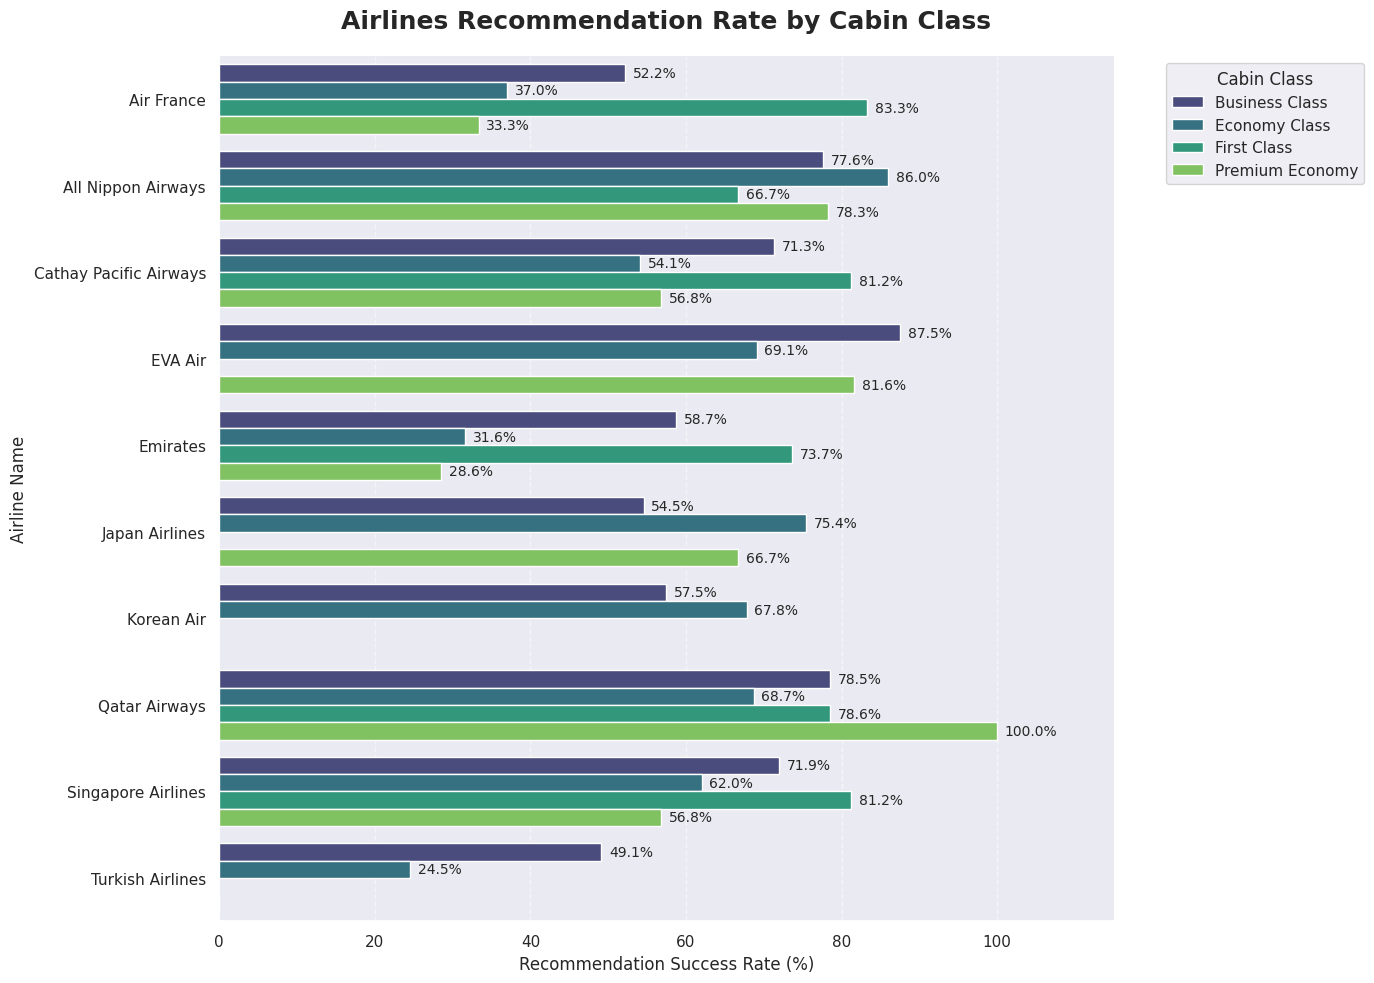

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. ส่วนการตั้งค่ากราฟ ---
plt.figure(figsize=(14, 10)) # ปรับความสูงเพิ่มขึ้นเพื่อให้ไม่อึดอัด

# ใช้ Palette 'RdYlGn' (แดง-เหลือง-เขียว) เหมือนรูปที่ 1
# หรือ 'viridis' เพื่อความทันสมัย
ax = sns.barplot(
    data=grouped_stats,
    x='Recommend_Percentage',
    y='Airline',
    hue='Class',
    palette='viridis'
)

# --- 3. ส่วนการเพิ่มตัวเลขกำกับปลายแท่ง (ให้เหมือนรูปที่ 1) ---
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 1,                # ตำแหน่ง X (ขยับไปทางขวานิดหน่อย)
            p.get_y() + p.get_height()/2, # ตำแหน่ง Y (กึ่งกลางแท่ง)
            f'{width:.1f}%',          # ข้อความตัวเลข
            va='center',
            fontsize=10
        )

# --- 4. ส่วนตกแต่ง Title และ Labels ---
plt.title('Airlines Recommendation Rate by Cabin Class', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Recommendation Success Rate (%)', fontsize=12)
plt.ylabel('Airline Name', fontsize=12)

# ย้าย Legend ออกไปข้างนอกเพื่อไม่ให้ทับแท่งกราฟ
plt.legend(title='Cabin Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlim(0, 115) # เผื่อที่ว่างด้านขวาไว้โชว์ตัวเลข %
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()

plt.show()

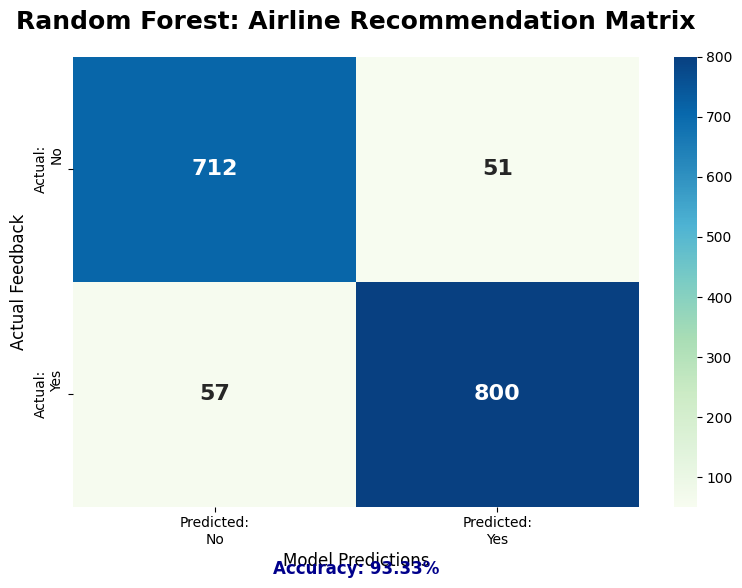

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings

# 1. ปิด Warning
warnings.filterwarnings('ignore')

# 2. รีเซ็ตค่า Matplotlib เป็นมาตรฐาน
plt.rcdefaults()

# 3. คำนวณ Confusion Matrix ใหม่ (ใช้ y_pred จาก RandomForest)
cm = confusion_matrix(y_test, y_pred)

# --- เริ่มวาดกราฟ ---
plt.figure(figsize=(8, 6))

# 4. สร้าง Heatmap (ใช้โทนสี 'GnBu' ที่ดูสะอาดตา)
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu',
            xticklabels=['Predicted:\nNo', 'Predicted:\nYes'],
            yticklabels=['Actual:\nNo', 'Actual:\nYes'],
            annot_kws={"size": 16, "fontweight": "bold"})

# 5. ตกแต่งหัวข้อเป็น Random Forest
plt.title('Random Forest: Airline Recommendation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Model Predictions', fontsize=12)
plt.ylabel('Actual Feedback', fontsize=12)

# เพิ่มคำอธิบาย Accuracy เล็กน้อยเพื่อให้กราฟดูสมบูรณ์
plt.annotate(f'\nAccuracy: {acc:.2%}', xy=(0.5, -0.15), xycoords='axes fraction',
             ha='center', fontsize=12, color='darkblue', fontweight='bold')

plt.tight_layout()
plt.show()

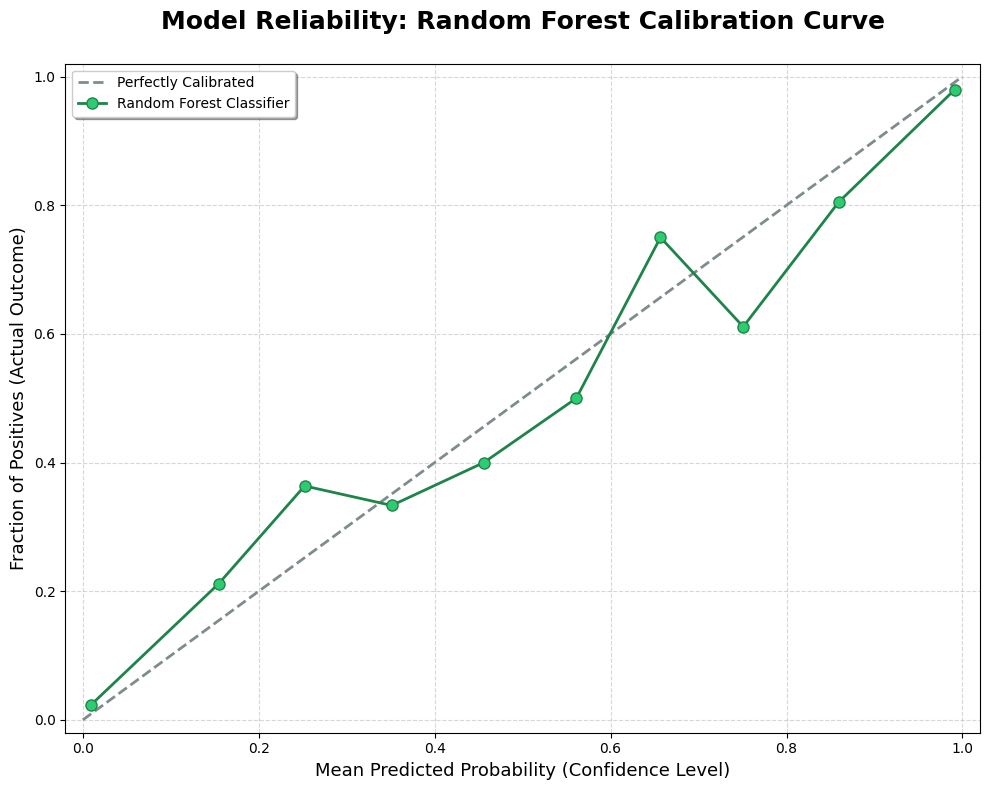

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
import warnings

# 1. ปิด Warning และตั้งค่าพื้นฐาน
warnings.filterwarnings('ignore')
plt.rcdefaults()

# 2. คำนวณค่าความน่าจะเป็น (Probability) จาก Random Forest
# ใช้ rf_model ที่เราเทรนไว้ (หรือ pipeline['classifier'] ถ้าใช้ pipeline)
rf_probs = pipeline.predict_proba(X_test)[:, 1]

# 3. สร้าง Calibration Curve
# ปรับ n_bins เป็น 10 เพื่อให้เห็นการกระจายตัวของความมั่นใจที่ชัดเจน
prob_true, prob_pred = calibration_curve(y_test, rf_probs, n_bins=10)

# 4. เริ่มวาดกราฟแบบ Modern Style
plt.figure(figsize=(10, 8))

# เส้นสมมติฐาน Perfect Calibration (เส้นที่โมเดลทายความแม่นยำได้ตรงกับความเป็นจริง 100%)
plt.plot([0, 1], [0, 1], linestyle='--', color='#7f8c8d', linewidth=2, label='Perfectly Calibrated')

# วาดเส้นของโมเดล Random Forest (ใช้สีเขียวเข้ม Emerald ให้ดูน่าเชื่อถือ)
plt.plot(prob_pred, prob_true, marker='o', markersize=8, color='#1e8449',
         linewidth=2, label='Random Forest Classifier', markerfacecolor='#2ecc71')

# 5. ตกแต่งหัวข้อเป็น Random Forest
plt.title('Model Reliability: Random Forest Calibration Curve', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Mean Predicted Probability (Confidence Level)', fontsize=13)
plt.ylabel('Fraction of Positives (Actual Outcome)', fontsize=13)

plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

# ปรับขอบเขตให้สวยงาม
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()